In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images folder if it doesn't exist
os.makedirs('images', exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load all datasets
campaigns = pd.read_csv('data/campaigns.csv')
customers = pd.read_csv('data/customers.csv')
purchases = pd.read_csv('data/purchases.csv')
sessions = pd.read_csv('data/website_sessions.csv')
daily = pd.read_csv('data/daily_performance.csv')
ab_test = pd.read_csv('data/ab_test.csv')
platforms = pd.read_csv('data/platforms.csv')
campaign_types = pd.read_csv('data/campaign_types.csv')

print("All datasets loaded.")

All datasets loaded.


In [3]:
# Calculate key metrics
total_campaigns = len(campaigns)
total_cost = campaigns['Cost'].sum()
total_revenue = campaigns['Revenue'].sum()
total_profit = campaigns['Revenue'].sum() - campaigns['Cost'].sum()
avg_roi = campaigns['ROI'].mean()
avg_conversion = campaigns['ConversionRate'].mean() * 100
profitable = (campaigns['Profit'] > 0).sum()
profitable_pct = profitable / total_campaigns * 100

# Display results
print("Campaign Performance Overview")
print("-" * 40)
print(f"Total campaigns: {total_campaigns:,}")
print(f"Total cost: ${total_cost:,.2f}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Average ROI: {avg_roi:.2f}%")
print(f"Average conversion rate: {avg_conversion:.2f}%")
print(f"Profitable campaigns: {profitable:,} ({profitable_pct:.1f}%)")

Campaign Performance Overview
----------------------------------------
Total campaigns: 10,000
Total cost: $614,839,603.15
Total revenue: $1,774,050,606.45
Total profit: $1,159,211,003.30
Average ROI: 176.06%
Average conversion rate: 5.17%
Profitable campaigns: 9,264 (92.6%)


In [4]:
# ROI statistics
roi_min = campaigns['ROI'].min()
roi_q1 = campaigns['ROI'].quantile(0.25)
roi_median = campaigns['ROI'].median()
roi_q3 = campaigns['ROI'].quantile(0.75)
roi_max = campaigns['ROI'].max()
roi_std = campaigns['ROI'].std()

print("ROI Distribution")
print("-" * 40)
print(f"Min: {roi_min:.2f}%")
print(f"Q1: {roi_q1:.2f}%")
print(f"Median: {roi_median:.2f}%")
print(f"Q3: {roi_q3:.2f}%")
print(f"Max: {roi_max:.2f}%")
print(f"Standard deviation: {roi_std:.2f}%")

ROI Distribution
----------------------------------------
Min: -30.00%
Q1: 156.81%
Median: 183.84%
Q3: 207.13%
Max: 1500.00%
Standard deviation: 130.79%


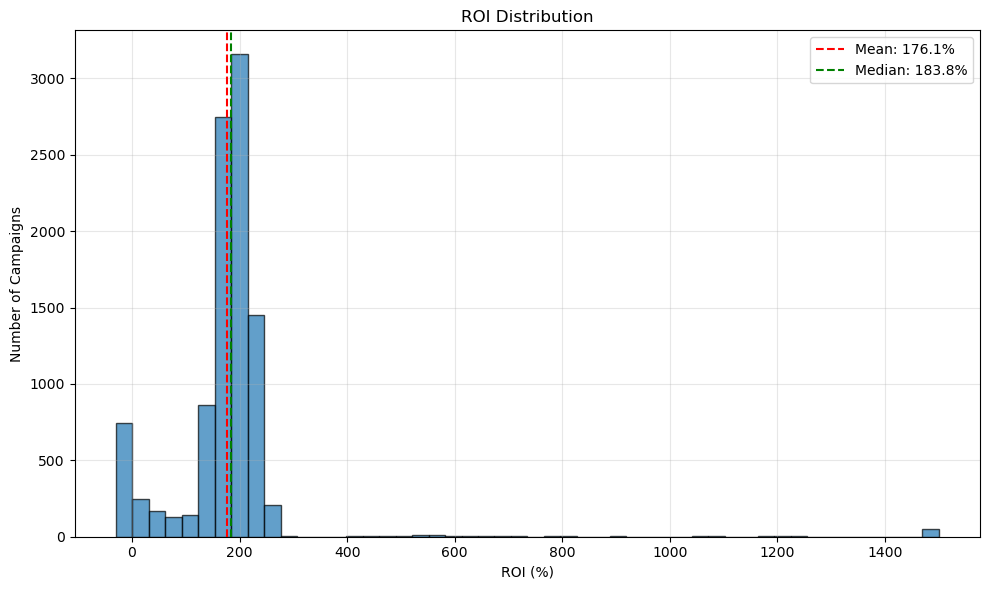

In [5]:
# Create histogram of ROI distribution
plt.figure(figsize=(10, 6))
plt.hist(campaigns['ROI'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(campaigns['ROI'].mean(), color='red', linestyle='--', label=f'Mean: {campaigns["ROI"].mean():.1f}%')
plt.axvline(campaigns['ROI'].median(), color='green', linestyle='--', label=f'Median: {campaigns["ROI"].median():.1f}%')
plt.xlabel('ROI (%)')
plt.ylabel('Number of Campaigns')
plt.title('ROI Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/roi_distribution.png', dpi=300)
plt.show()

In [6]:
# Merge campaigns with platforms
campaigns_platform = campaigns.merge(platforms, on='PlatformID')

# Calculate performance by platform
platform_summary = campaigns_platform.groupby('PlatformName').agg({
    'CampaignID': 'count',
    'ROI': 'mean',
    'Revenue': 'sum',
    'Cost': 'sum'
}).round(2)

platform_summary.columns = ['Campaigns', 'Avg ROI (%)', 'Revenue', 'Cost']
platform_summary = platform_summary.sort_values('Avg ROI (%)', ascending=False)

print("Platform Performance Summary")
print("-" * 40)
print(platform_summary.to_string())

Platform Performance Summary
----------------------------------------
              Campaigns  Avg ROI (%)       Revenue          Cost
PlatformName                                                    
Google Ads         1374       206.48  6.656940e+08  2.146929e+08
TikTok             1465       192.48  2.808918e+08  9.584835e+07
Instagram          1431       184.42  2.505399e+08  8.877112e+07
YouTube            1430       177.59  2.811175e+08  9.957317e+07
Facebook           1420       167.22  1.102182e+08  4.088968e+07
X (Twitter)        1419       157.59  5.062319e+07  1.987271e+07
LinkedIn           1461       147.84  1.349661e+08  5.519170e+07


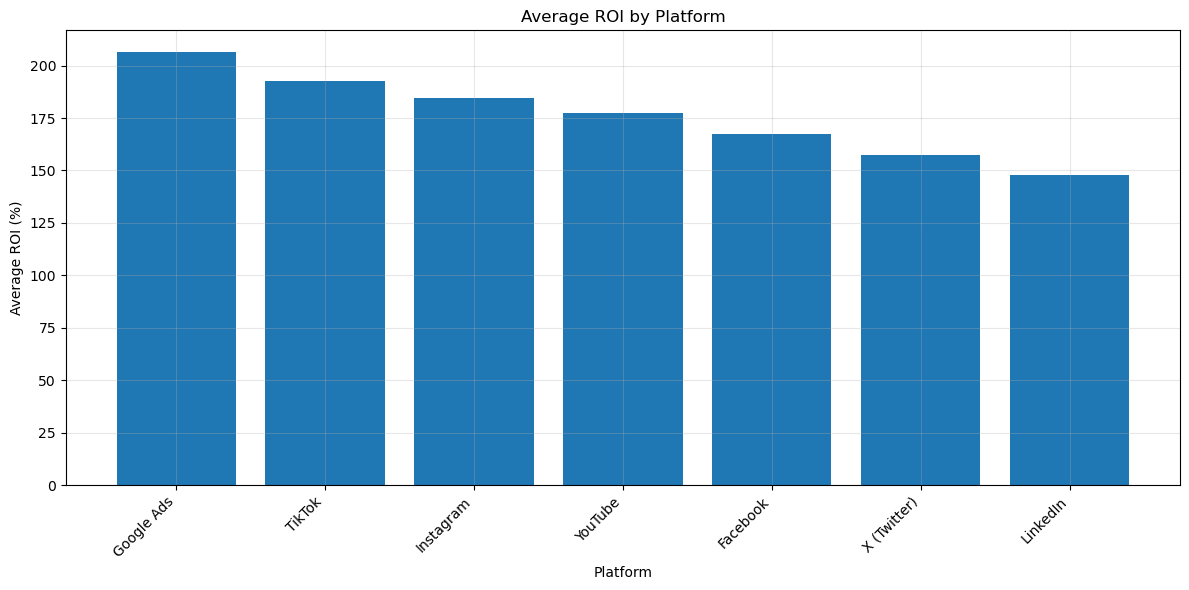

In [7]:
# Bar chart of ROI by platform
plt.figure(figsize=(12, 6))
platforms_sorted = platform_summary.sort_values('Avg ROI (%)', ascending=False)
plt.bar(platforms_sorted.index, platforms_sorted['Avg ROI (%)'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Platform')
plt.ylabel('Average ROI (%)')
plt.title('Average ROI by Platform')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/platform_roi.png', dpi=300)
plt.show()

In [8]:
# Merge campaigns with campaign types
campaigns_type = campaigns.merge(campaign_types, on='CampaignTypeID')

# Calculate performance by campaign type
type_summary = campaigns_type.groupby('CampaignType').agg({
    'CampaignID': 'count',
    'ConversionRate': 'mean',
    'ROI': 'mean'
}).round(4)

type_summary.columns = ['Campaigns', 'Conversion Rate', 'Avg ROI (%)']
type_summary['Conversion Rate'] = type_summary['Conversion Rate'] * 100
type_summary = type_summary.sort_values('Conversion Rate', ascending=False)

print("Campaign Type Performance")
print("-" * 40)
print(type_summary.to_string())

Campaign Type Performance
----------------------------------------
              Campaigns  Conversion Rate  Avg ROI (%)
CampaignType                                         
Search             1624             6.40     177.2246
Retargeting        1688             6.04     177.1681
Video              1686             5.66     181.0450
Social             1692             5.02     172.9900
Email              1682             4.28     172.3954
Display            1628             3.59     175.5690


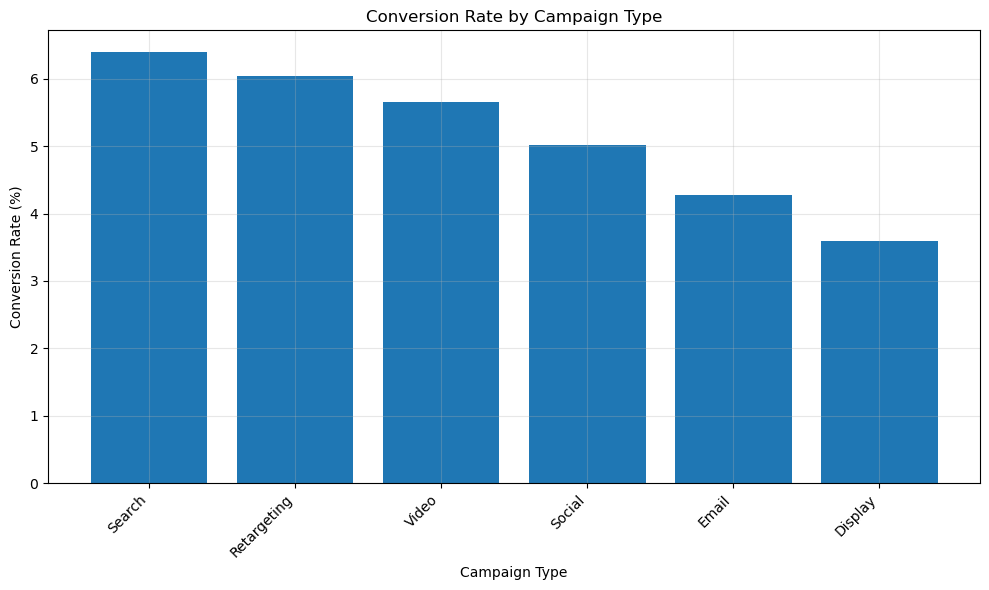

In [9]:
# Bar chart of conversion rate by campaign type
plt.figure(figsize=(10, 6))
plt.bar(type_summary.index, type_summary['Conversion Rate'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Campaign Type')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Campaign Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/campaign_type_conversion.png', dpi=300)
plt.show()

In [10]:
# CLV by customer segment
segment_summary = customers.groupby('CustomerSegment').agg({
    'CustomerID': 'count',
    'CustomerLifetimeValue': 'mean'
}).round(2)

segment_summary.columns = ['Customers', 'Avg CLV']
segment_summary = segment_summary.sort_values('Avg CLV', ascending=False)

print("Customer Segment Analysis")
print("-" * 40)
print(segment_summary.to_string())

Customer Segment Analysis
----------------------------------------
                 Customers   Avg CLV
CustomerSegment                     
Platinum               895  36835.81
Gold                  1172  21134.19
Silver                1482   9212.21
Bronze                1451   4995.08


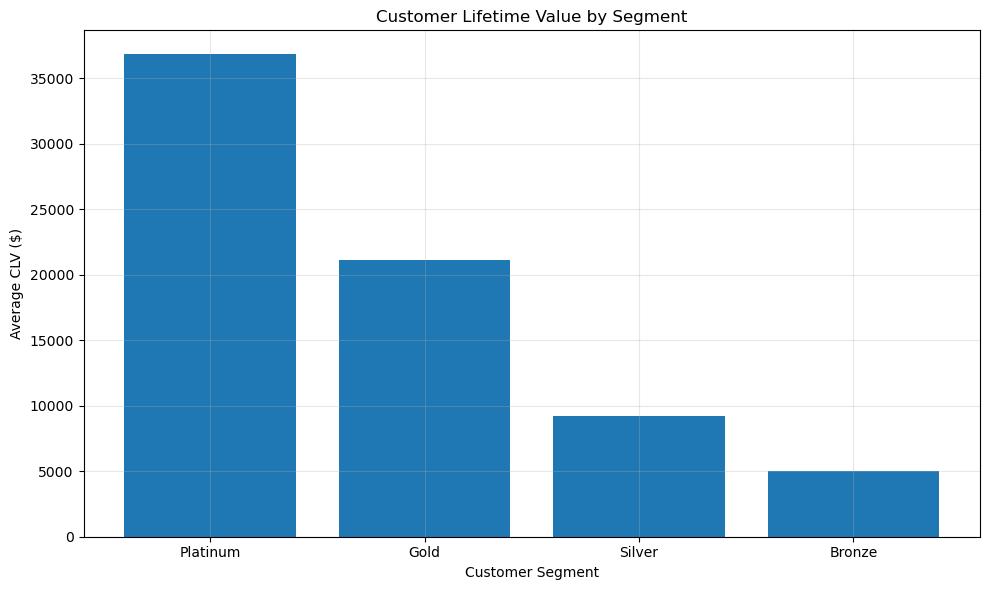

In [11]:
# Bar chart of CLV by customer segment
plt.figure(figsize=(10, 6))
plt.bar(segment_summary.index, segment_summary['Avg CLV'])
plt.xlabel('Customer Segment')
plt.ylabel('Average CLV ($)')
plt.title('Customer Lifetime Value by Segment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/clv_by_segment.png', dpi=300)
plt.show()

In [12]:
# Conversion rate by device
device_conv = sessions.groupby('Device')['Converted'].mean() * 100

print("Conversion Rate by Device")
print("-" * 40)
for device, rate in device_conv.items():
    print(f"{device}: {rate:.2f}%")

Conversion Rate by Device
----------------------------------------
Desktop: 13.10%
Mobile: 10.96%
Tablet: 12.27%


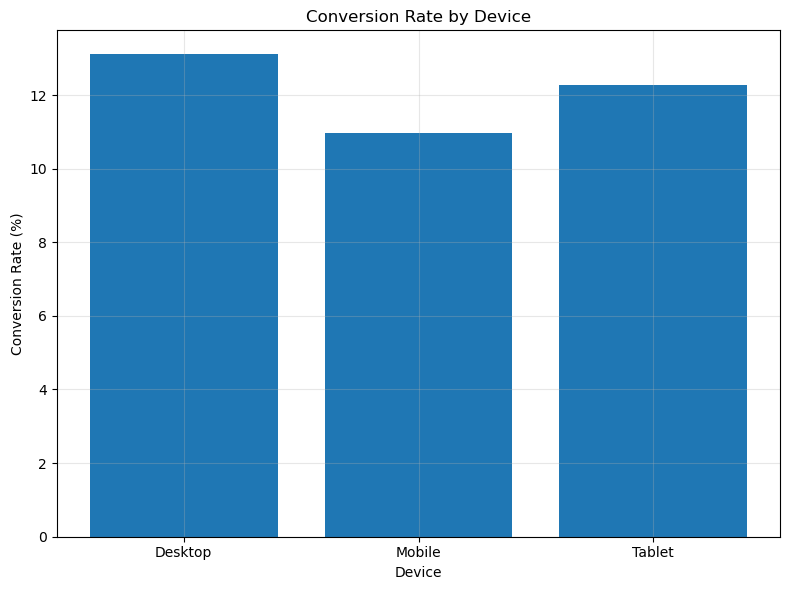

In [13]:
# Bar chart of conversion rate by device
plt.figure(figsize=(8, 6))
plt.bar(device_conv.index, device_conv.values)
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Device')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/device_conversion.png', dpi=300)
plt.show()

In [14]:
# Convert date and extract month
daily['Date'] = pd.to_datetime(daily['Date'])
daily['Month'] = daily['Date'].dt.month
daily['Month_Name'] = daily['Date'].dt.strftime('%b')

# Monthly revenue
monthly_revenue = daily.groupby(['Month', 'Month_Name'])['DailyRevenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Month')

print("Monthly Revenue")
print("-" * 40)
for _, row in monthly_revenue.iterrows():
    print(f"{row['Month_Name']}: ${row['DailyRevenue']/1e6:.1f}M")

Monthly Revenue
----------------------------------------
Jan: $37.9M
Feb: $33.2M
Mar: $37.6M
Apr: $42.6M
May: $45.3M
Jun: $44.6M
Jul: $33.3M
Aug: $35.4M
Sep: $48.8M
Oct: $61.8M
Nov: $51.6M
Dec: $62.9M


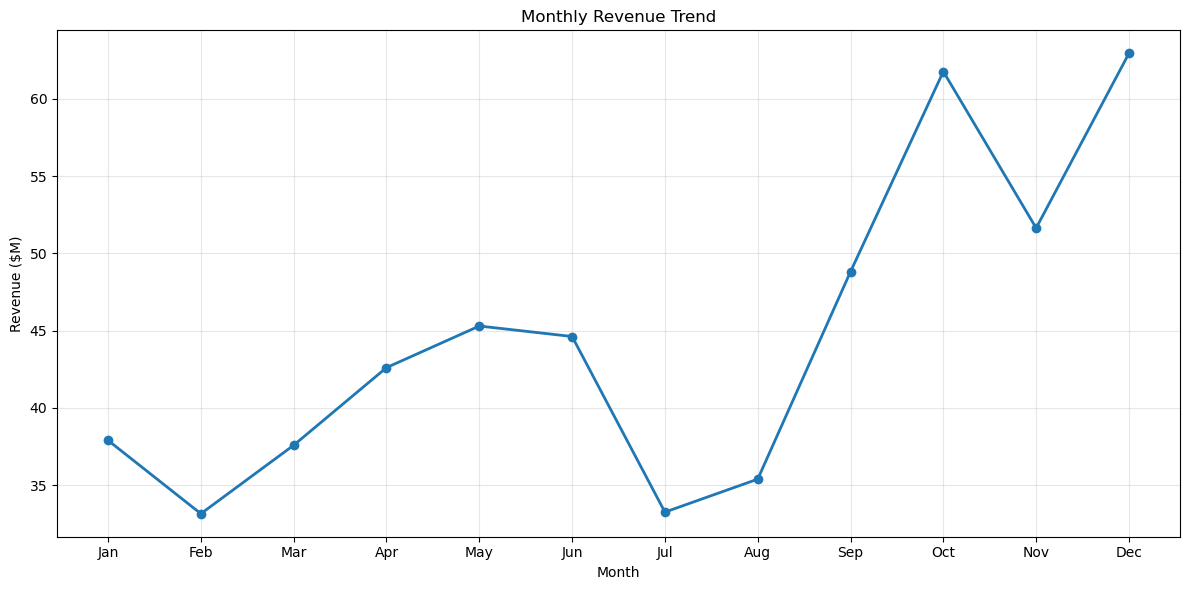

In [15]:
# Line chart of monthly revenue
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['Month_Name'], monthly_revenue['DailyRevenue'] / 1e6, marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Revenue ($M)')
plt.title('Monthly Revenue Trend')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/monthly_revenue.png', dpi=300)
plt.show()

In [16]:
# Calculate A/B test results
ab_summary = ab_test.groupby('Variant').agg({
    'TestID': 'count',
    'Conversions': 'sum',
    'Visitors': 'sum'
}).reset_index()

ab_summary['Conversion Rate'] = (ab_summary['Conversions'] / ab_summary['Visitors']) * 100

print("A/B Test Results")
print("-" * 40)
print(ab_summary.to_string(index=False))

A/B Test Results
----------------------------------------
Variant  TestID  Conversions  Visitors  Conversion Rate
      A     505       240902   4028446         5.980023
      B     495       288284   3886072         7.418391


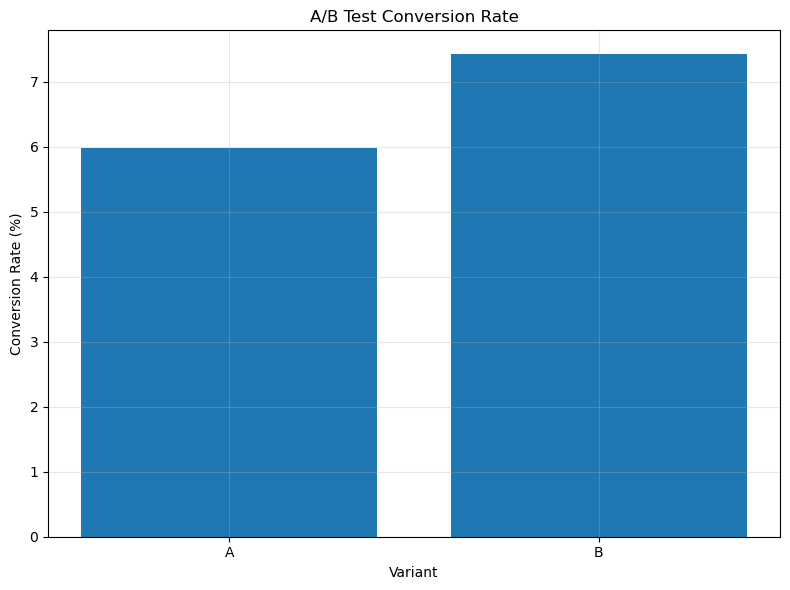

In [17]:
# Bar chart of A/B test conversion rates
plt.figure(figsize=(8, 6))
plt.bar(ab_summary['Variant'], ab_summary['Conversion Rate'])
plt.xlabel('Variant')
plt.ylabel('Conversion Rate (%)')
plt.title('A/B Test Conversion Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/ab_test_results.png', dpi=300)
plt.show()

In [18]:
print("EDA Summary")
print("-" * 40)

print("\nKey Findings:")
print("1. Platform Performance:")
print(f"   Highest ROI: {platform_summary.index[0]} ({platform_summary.iloc[0]['Avg ROI (%)']:.1f}%)")
print(f"   Lowest ROI: {platform_summary.index[-1]} ({platform_summary.iloc[-1]['Avg ROI (%)']:.1f}%)")

print("\n2. Campaign Type Performance:")
print(f"   Highest conversion: {type_summary.index[0]} ({type_summary.iloc[0]['Conversion Rate']:.2f}%)")
print(f"   Lowest conversion: {type_summary.index[-1]} ({type_summary.iloc[-1]['Conversion Rate']:.2f}%)")

print("\n3. Customer Segments:")
print(f"   Highest CLV: {segment_summary.index[0]} (${segment_summary.iloc[0]['Avg CLV']:,.2f})")
print(f"   Lowest CLV: {segment_summary.index[-1]} (${segment_summary.iloc[-1]['Avg CLV']:,.2f})")

print("\n4. Devices:")
best_device = device_conv.idxmax()
worst_device = device_conv.idxmin()
print(f"   Best converting: {best_device} ({device_conv[best_device]:.2f}%)")
print(f"   Worst converting: {worst_device} ({device_conv[worst_device]:.2f}%)")

print("\n5. Seasonality:")
best_month = monthly_revenue.loc[monthly_revenue['DailyRevenue'].idxmax(), 'Month_Name']
worst_month = monthly_revenue.loc[monthly_revenue['DailyRevenue'].idxmin(), 'Month_Name']
print(f"   Best month: {best_month} (${monthly_revenue['DailyRevenue'].max()/1e6:.1f}M)")
print(f"   Worst month: {worst_month} (${monthly_revenue['DailyRevenue'].min()/1e6:.1f}M)")


EDA Summary
----------------------------------------

Key Findings:
1. Platform Performance:
   Highest ROI: Google Ads (206.5%)
   Lowest ROI: LinkedIn (147.8%)

2. Campaign Type Performance:
   Highest conversion: Search (6.40%)
   Lowest conversion: Display (3.59%)

3. Customer Segments:
   Highest CLV: Platinum ($36,835.81)
   Lowest CLV: Bronze ($4,995.08)

4. Devices:
   Best converting: Desktop (13.10%)
   Worst converting: Mobile (10.96%)

5. Seasonality:
   Best month: Dec ($62.9M)
   Worst month: Feb ($33.2M)
